## Imports ##

In [150]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import trapezoid
import matplotlib.ticker as ticker

## Verifying Results of Different Moon Sublimation Rates (Andreas et al. 2007) ##

In [11]:
def buck_e_sat_i(T): # T: [193.15-273.15]
    numerator = 22.542 * (T - 273.15)
    denominator = 273.48 + (T - 273.15)
    e_sat = 100*6.1115 * math.exp(numerator / denominator)
    return e_sat


def wag_e_sat_i(T): # [190, 273.16]
    """Calculate the saturation vapor pressure over ice for a given temperature T (in Kelvin)."""
    term1 = -13.9281690 * (1 - (T / 273.16) ** -1.5)
    term2 = 34.7078238 * (1 - (T / 273.16) ** -1.25)
    e_sat = 100*6.11657 * math.exp(term1 + term2)
    return e_sat

def murph_coop_e_sat_i(T): # [110, 273.15]
    exponent = (
        9.550426
        - (5723.265 / T)
        + 3.53068 * math.log(T)
        - 0.00728332 * T
    )
    e_sat = 100*0.01 * math.exp(exponent)
    return e_sat

# Example usage:
temperature_K = 200  # for example, 260 K
print(f"Saturation vapor pressure over ice at {temperature_K} K: {buck_e_sat_i(temperature_K):.10f} Pa")
print(f"Saturation vapor pressure over ice at {temperature_K} K: {wag_e_sat_i(temperature_K):.10f} Pa")
print(f"Saturation vapor pressure over ice at {temperature_K} K: {murph_coop_e_sat_i(temperature_K):.10f} Pa")

Saturation vapor pressure over ice at 200 K: 0.1627056293 Pa
Saturation vapor pressure over ice at 200 K: 0.1622651822 Pa
Saturation vapor pressure over ice at 200 K: 0.1626914462 Pa


## Plotting Sublimation Rates for Moons w/ Thin Atmospheres (Andreas 2006): Spherical Ice Planes w/ Curvature Effects ##

$$
S_{0} = e_{sat,i}(T)(\frac{M_{w}}{2 \pi RT})^{0.5}
$$

$$
e_{sat,i}(T) = 0.01 * exp(9.550426-\frac{5723.265}{T}+3.53068lnT-0.00728332T)
$$

In [42]:
m_w = 18.015e-3 # kg/mol
R = 8.31447 # J/mol*K
rho_ice = 917 #kg/m^3

T_moon = 170 # assumes surface temperature of 170 K for Moon
T_callisto = 135 # average surface temperature of Callisto 

s_0_moon = murph_coop_e_sat_i(T_moon)*(m_w/(2*np.pi*R*T_moon))**0.5 # test case
s_0_callisto = murph_coop_e_sat_i(T_callisto)*(m_w/(2*np.pi*R*T_callisto))**0.5

In [44]:
s_0_moon_m = (s_0_moon/(rho_ice)*(24*60*60*365.25))*1000
s_0_callisto_m = (s_0_callisto/(rho_ice)*(24*60*60*365.25))*1000

print(f"Moon Sublimation rate: {s_0_moon_m:.2e} mm/year")
print(f"Callisto Sublimation rate: {s_0_callisto_m:.2e} mm/year")

Moon Sublimation rate: 3.58e+01 mm/year
Callisto Sublimation rate: 3.72e-03 mm/year


In [46]:
def rho_i(T):
    """Calculate the density of ice (ρ_i) for a given temperature T (in Kelvin)."""
    delta_T = T - 273.15
    rho = 916.7 - 0.175 * delta_T - 5.0e-4 * (delta_T ** 2)
    return rho

def m_t_sphere(m_0, rho_i, r_c, r_0, s_0, t):
    t1 = (s_0*t)/(rho_i*(r_0-r_c))
    m_t = m_0*(1-t1)**3
    return m_t

# Mental verification check:
temperature_K = 252
print(f"Density of ice at {temperature_K} K: {rho_i(temperature_K):.2f} kg/m³")

Density of ice at 252 K: 920.18 kg/m³


$$
\frac{m(t)}{m_0} = (1 - \frac{S_0 t}{\rho_i (r_0-r_{c})})^3
$$

In [49]:
r_0 = 1e-4 # initial radius of ice in m from paper
sigma_i = 0.109 # J/m^2, surface tension of a pure ice/vapor interface

rho_i_moon = rho_i(T_moon)
rho_i_callisto = rho_i(T_callisto)

t = np.linspace(0, 10**4, 1000)

r_c_moon = (2*m_w*sigma_i)/(rho_i_moon*R*T_moon)
r_c_callisto = (2*m_w*sigma_i)/(rho_i_callisto*R*T_callisto)

m_0_moon = (4/3)*np.pi*(r_0)**3*rho_i_moon # initial mass of ice in kg
m_0_callisto = (4/3)*np.pi*(r_0)**3*rho_i_callisto # initial mass of ice in kg

m_t_moon = m_t_sphere(m_0_moon, rho_i_moon, r_c_moon, r_0, s_0_moon, t)
m_t_callisto = m_t_sphere(m_0_callisto, rho_i_callisto, r_c_callisto, r_0, s_0_callisto, t)

m_moon = (m_t_moon/m_0_moon)*100 # Percentage
m_callisto = (m_t_callisto/m_0_callisto)*100

In [51]:
t_f = ((m_0_moon*rho_i_moon**2)/(s_0_moon**3))**(1/3)
t_f

143911.9807504034

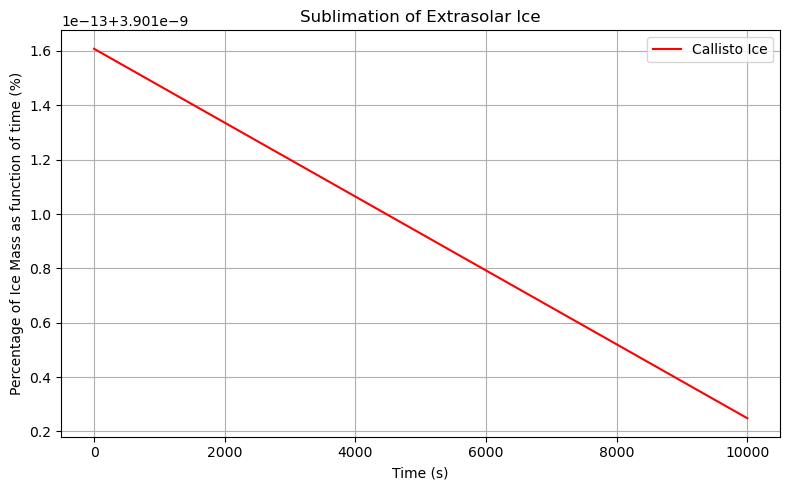

In [53]:
plt.figure(figsize=(8, 5))
# plt.plot(t, m_t_moon, label='Lunar Ice', color='blue')  # Convert t to hours
plt.plot(t, m_t_callisto, label="Callisto Ice", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Percentage of Ice Mass as function of time (%)')
plt.title('Sublimation of Extrasolar Ice')
#plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

#plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

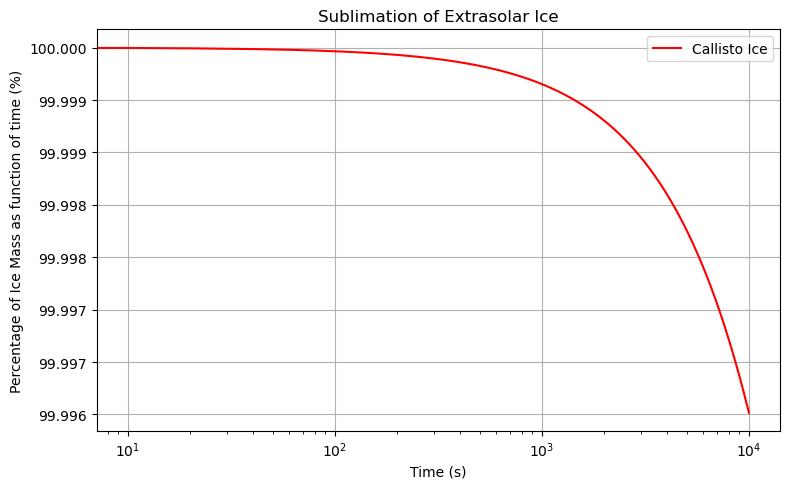

In [55]:
plt.figure(figsize=(8, 5))
# plt.plot(t, m_moon, label='Lunar Ice', color='blue')  # Convert t to hours
plt.plot(t, m_callisto, label="Callisto Ice", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Percentage of Ice Mass as function of time (%)')
plt.title('Sublimation of Extrasolar Ice')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

In [57]:
t_fin_moon = ((r_0-r_c_moon)*rho_i_moon)/(s_0_moon)
t_fin_callisto = ((r_0-r_c_callisto)*rho_i_callisto)/(s_0_callisto)

# print(f'It will take {t_fin_moon/86400} days for {m_0_moon} kg of lunar ice to sublimate')
print(f'It will take {t_fin_callisto/31536000} years for {m_0_callisto} kg of ice on Callisto to sublimate')

It will take 27.29957948405248 years for 3.901160804505047e-09 kg of ice on Callisto to sublimate


## Plotting Sublimation Rates for Moons w/ Thin Atmospheres (Andreas 2006): Cubic Ice Planes w/o Curvature Effects ##

$$
r(t) = r_{0}-\frac{s_0t}{\rho_i}
$$

$$
m(t) = \rho_i(r_0 - \frac{S_0 t}{\rho_i})^3
$$

In [87]:
def m_t_cube(rho_i, r_0, s_0, t):
    t1 = (r_0-((s_0*t)/(rho_i*r_0)))
    m_t = rho_i*t1**3
    return m_t

In [89]:
r_0 = 1 # initial radius of ice in m

rho_i_moon = rho_i(T_moon)
rho_i_callisto = rho_i(T_callisto)

t = np.linspace(0, 10**5, 1000)

m_0_moon_cube = (r_0)**3*rho_i_moon # initial mass of ice in kg
m_0_callisto_cube = (r_0)**3*rho_i_callisto # initial mass of ice in kg

m_t_moon_cube = m_t_cube(rho_i_moon, r_0, s_0_moon, t)
m_t_callisto_cube = m_t_cube(rho_i_callisto, r_0, s_0_callisto, t)

m_moon_cube = (m_t_moon_cube/m_0_moon_cube)*100 # Percentage
m_callisto_cube = (m_t_callisto_cube/m_0_callisto_cube)*100

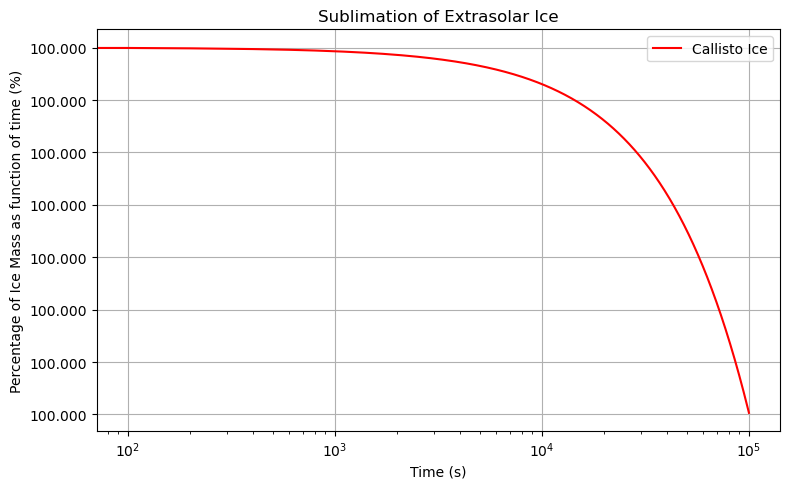

In [93]:
plt.figure(figsize=(8, 5))
# plt.plot(t, m_moon_cube, label='Lunar Ice', color='blue')  # Convert t to hours
plt.plot(t, m_callisto_cube, label="Callisto Ice", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Percentage of Ice Mass as function of time (%)')
plt.title('Sublimation of Extrasolar Ice')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

In [95]:
# t_f_cube_moon = ((r_0*rho_i_moon)/(s_0_moon))
t_f_cube_callisto = ((r_0*rho_i_callisto)/(s_0_callisto))

# print(f'It will take {t_f_cube_moon/31536000} years for {m_0_moon_cube} kg of lunar ice to sublimate')
print(f'It will take {t_f_cube_callisto/31536000} years for {m_0_callisto_cube} kg of ice on Callisto to sublimate')

It will take 273006.0511106657 years for 931.33353875 kg of ice on Callisto to sublimate


## Plotting Sublimation Rates for Moons w/ Thin Atmospheres (Andreas 2006): Large Ice Planes w/o Curvature Effects ##

In [98]:
def m_0_plane_column(rho_i, r_0):
    mass_column = rho_i*r_0 # units of kg/m^2
    return mass_column

In [100]:
def m_t_plane_column(rho_i, r_0, s_0, t):
    h_t = r_0 - (s_0*t)/rho_i
    mass_column = rho_i*h_t
    return mass_column

In [102]:
r_0 = 1 # initial radius of ice in m

rho_i_moon = rho_i(T_moon)
rho_i_callisto = rho_i(T_callisto)

t = np.linspace(0, 10**8, 1000)

m_0_moon_plane = m_0_plane_column(rho_i_moon, r_0) # initial mass of ice in kg
m_0_callisto_plane = m_0_plane_column(rho_i_callisto, r_0) # initial mass of ice in kg

m_t_moon_plane = m_t_plane_column(rho_i_moon, r_0, s_0_moon, t)
m_t_callisto_plane = m_t_plane_column(rho_i_callisto, r_0, s_0_callisto, t)

m_moon_plane = (m_t_moon_plane/m_0_moon_plane)*100 # Percentage
m_callisto_plane = (m_t_callisto_plane/m_0_callisto_plane)*100

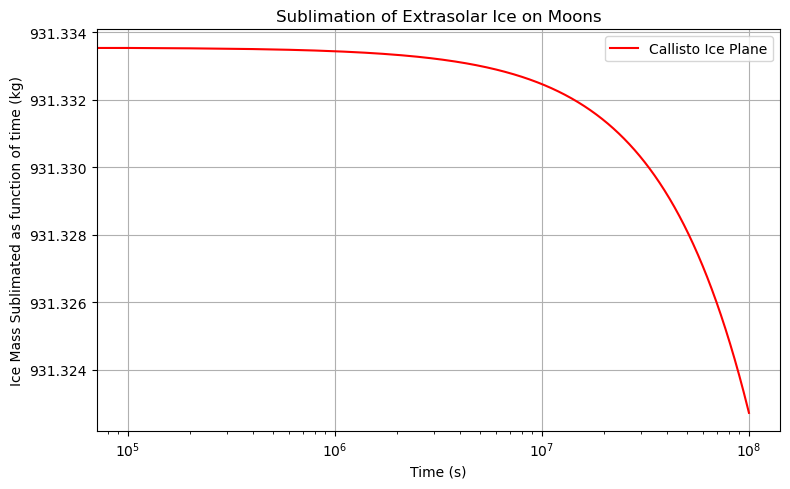

In [108]:
plt.figure(figsize=(8, 5))
# plt.plot(t, m_t_moon_plane, label='Lunar Ice Plane', color='blue')  # Convert t to hours
plt.plot(t, m_t_callisto_plane, label="Callisto Ice Plane", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Ice Mass Sublimated as function of time (kg)')
plt.title('Sublimation of Extrasolar Ice on Moons')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

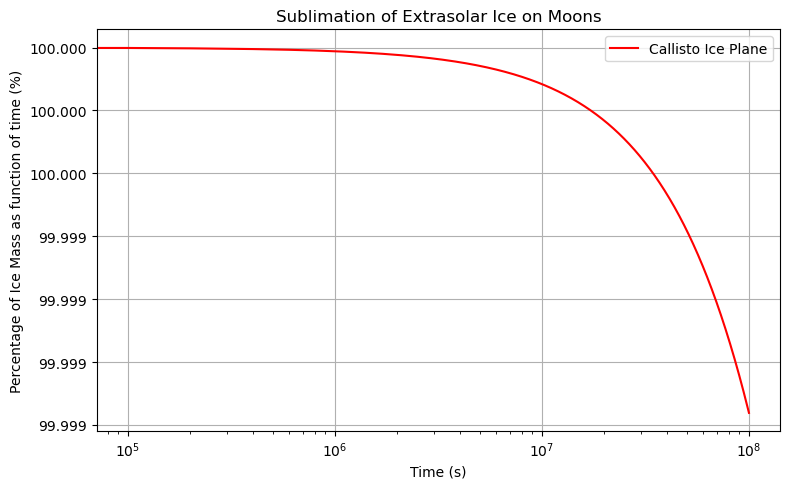

In [114]:
plt.figure(figsize=(8, 5))
# plt.plot(t, m_moon_plane, label='Lunar Ice Plane', color='blue')  # Convert t to hours
plt.plot(t, m_callisto_plane, label="Callisto Ice Plane", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Percentage of Ice Mass as function of time (%)')
plt.title('Sublimation of Extrasolar Ice on Moons')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

In [118]:
# t_f_plane_moon = ((r_0*rho_i_moon)/(s_0_moon))
t_f_plane_callisto = ((r_0*rho_i_callisto)/(s_0_callisto))

# print(f'It will take {t_f_plane_moon/31536000} years for {m_0_moon_plane} kg of lunar ice to sublimate')
print(f'It will take {t_f_plane_callisto/31536000} years for {m_0_callisto_plane} kg of ice on Callisto to sublimate')

It will take 273006.0511106657 years for 931.33353875 kg of ice on Callisto to sublimate


## Plotting Sublimation Rates on Planets w/ Atmospheres (Wordsworth et al. 2015) ##

$$
\mathcal{S}_{\text{pot}} \equiv \frac{-C_D |\mathbf{v}|}{R_{\mathrm{H_2O}} T_a}{p_{\text{sat}}(T_s)}
$$

$$
p_{sat} = p_{0}*exp(\frac{-L}{R_{H2O}}(\frac{1}{T}-\frac{1}{T_{0}}))
$$

In [122]:
v = 5 # m/s, surface wind speed
t_a = 220 # K, temp of lowest atmospheric layer
t_s = t_a # surface temp
r_h20 = 461.5 # J/kg * K
c_d = 2.75e-3 # drag coefficient
t_0 = 273.15 # K, reference temperature

p_0 = 610.78  # Pa, sublimation vapor pressure of ice at 273.15 K
l = 2.849e6 # J/kg # latent heat of vaporization/sublimation, energy needed to change phase (ice-> vapor), for water ice 

p_sat = p_0 * np.e**((-l/r_h20)*((1/t_s)-(1/t_0)))
p_sat

2.597742331665074

In [124]:
s_pot = ((-c_d*np.abs(v)*p_sat)/(r_h20*t_a)) # kg/m^2/s
s_pot_mm = ((((-c_d*np.abs(v)*p_sat)/(r_h20*t_a))/(rho_ice))*(24*60*60*365.25))*1000
print(f'The sublimation rate of ice on Mars is {s_pot} kg/m^2/s')
print(f'The sublimation rate of ice on Mars is {s_pot_mm} mm/year')

The sublimation rate of ice on Mars is -3.518069246567001e-07 kg/m^2/s
The sublimation rate of ice on Mars is -12.10706892644087 mm/year


In [126]:
rho_ice = 917 #kg/m^3
len_ice = 1 # m
width_ice = 1 # m
depth_ice = 1 # m
volume_ice = len_ice*width_ice*depth_ice #m^3 (5 meters deep, 10 meters long, 2 meters wide)
area_ice = 2*(len_ice*width_ice+len_ice*depth_ice+width_ice*depth_ice) # m^2 (assuming all planes of the cube are exposed to sublimation - A=2(lw+ld+wd))

m_0 = rho_ice*volume_ice
mass_column_ice = rho_ice*depth_ice #kg/m^2

t_cube = np.abs(m_0/(area_ice*s_pot))/ 31536000 #divided by number of seconds in a non-leap year year
t_column = np.abs(mass_column_ice/s_pot)/31536000
print(f'It would take ~ {t_cube} years to sublimate a cube of {m_0} kg of ice of dimensions: {len_ice} m in length, {width_ice} m wide, and {depth_ice} m deep.')
print(f'It would take ~ {t_column} years to sublimate a column of {mass_column_ice} kg/m^2 of ice.')

It would take ~ 13.775491238310558 years to sublimate a cube of 917 kg of ice of dimensions: 1 m in length, 1 m wide, and 1 m deep.
It would take ~ 82.65294742986335 years to sublimate a column of 917 kg/m^2 of ice.


In [128]:
thickness_per_year = depth_ice/t_cube
thickness_per_year_plane = depth_ice/t_column

print(f"Cube Ice thickness lost per year: {thickness_per_year:.6f} m/year")
print(f"Plane Ice thickness lost per year: {thickness_per_year_plane:.6f} m/year")

Cube Ice thickness lost per year: 0.072593 m/year
Plane Ice thickness lost per year: 0.012099 m/year


In [130]:
t = np.linspace(0, 10**8, 1000)

m_t_mars_cube = m_t_cube(rho_ice, len_ice, -s_pot, t)
m_t_mars_plane = m_t_plane_column(rho_ice, depth_ice, -s_pot, t)

m_mars_cube = (m_t_mars_cube/m_0)*100 # Percentage
m_mars_plane = (m_t_mars_plane/mass_column_ice)*100 # Percentage

## Sublimation Rates on Ceres ##

$$
\mathcal{S} = \alpha \, \frac{p_{\text{sat}}(T)}{\sqrt{2 \pi m k_B T}}
$$

In [134]:
# Constants
T = 166.0  # K
L = 2.849e6  # J/kg
R_H2O = 461.5  # J/(kg*K)
T0 = 273.15  # K
p0 = 611.0  # Pa
alpha = 1.0
m = 2.991e-26  # kg
kB = 1.38e-23  # J/K

# Saturation pressure
psat = p0 * np.exp(-L / R_H2O * (1/T - 1/T0))

# Hertz–Knudsen sublimation rate
S = (((alpha * psat) / np.sqrt(2 * np.pi * m * kB * T)*m)/(rho_ice))*(24*60*60*365.25) # Was getting value in sublimated molecules, dividied by m again and tehn by density to get thickness/s, and then by the number of seconds in a year
print(f"Sublimation rate: {S:.2e} m/yr")

Sublimation rate: 1.40e-02 m/yr


In [140]:
# Hertz–Knudsen sublimation rate
S = ((alpha * psat) / np.sqrt(2 * np.pi * m * kB * T)*m) # kg/m^2/s
print(f"Sublimation rate: {S:.2e} kg/m^2/s")

S_mm = (S/(rho_ice)*(24*60*60*365.25))*1000 # Was getting value in sublimated molecules, dividied by m again and tehn by density to get thickness/s, and then by the number of seconds in a year
print(f"Sublimation rate: {S_mm:.2e} mm/yr")

m_t_ceres_plane = m_t_plane_column(rho_ice, depth_ice, S, t)

m_ceres_plane = (m_t_ceres_plane/mass_column_ice)*100 # Percentage

Sublimation rate: 4.07e-07 kg/m^2/s
Sublimation rate: 1.40e+01 mm/yr


In [144]:
rho_ice = 917 #kg/m^3
len_ice = 1 # m
width_ice = 1 # m
depth_ice = 1 # m
volume_ice = len_ice*width_ice*depth_ice #m^3 (5 meters deep, 10 meters long, 2 meters wide)
area_ice = 2*(len_ice*width_ice+len_ice*depth_ice+width_ice*depth_ice) # m^2 (assuming all planes of the cube are exposed to sublimation - A=2(lw+ld+wd))

m_0 = rho_ice*volume_ice
mass_column_ice = rho_ice*depth_ice #kg/m^2

t_cube = np.abs(m_0/(area_ice*S))/ 31536000 # divided by number of seconds in a non-leap year year
t_column = np.abs(mass_column_ice/S)/31536000
print(f'It would take ~ {t_cube} years to sublimate a cube of {m_0} kg of ice of dimensions: {len_ice} m in length, {width_ice} m wide, and {depth_ice} m deep.')
print(f'It would take ~ {t_column} years to sublimate a column of {mass_column_ice} kg/m^2 of ice.')

thickness_per_year = depth_ice/t_cube
thickness_per_year_plane = depth_ice/t_column

print(f"Cube Ice thickness lost per year: {thickness_per_year:} m/year")
print(f"Plane Ice thickness lost per year: {thickness_per_year_plane:} m/year")

It would take ~ 11.916489063098211 years to sublimate a cube of 917 kg of ice of dimensions: 1 m in length, 1 m wide, and 1 m deep.
It would take ~ 71.49893437858928 years to sublimate a column of 917 kg/m^2 of ice.
Cube Ice thickness lost per year: 0.08391733460291587 m/year
Plane Ice thickness lost per year: 0.013986222433819308 m/year


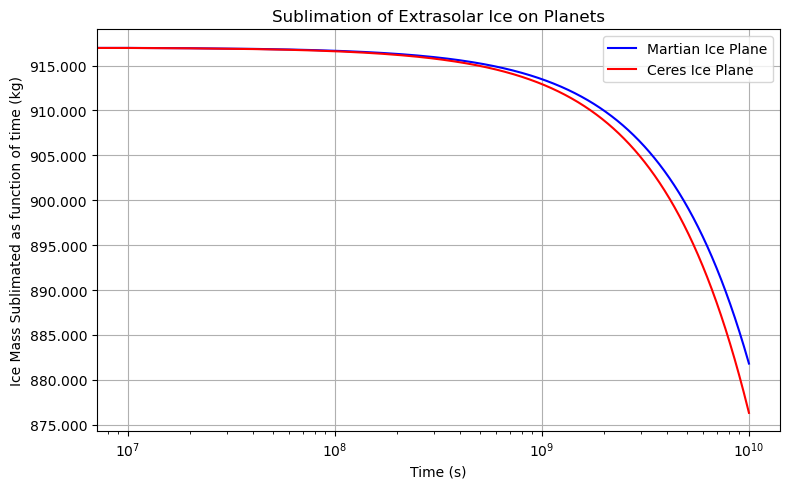

In [146]:
t=np.linspace(0,10**10, 1000)

plt.figure(figsize=(8, 5))
plt.plot(t, m_t_mars_plane, label='Martian Ice Plane', color='blue')  # Convert t to hours
plt.plot(t, m_t_ceres_plane, label="Ceres Ice Plane", color='red')  # Convert t to hours
plt.xlabel('Time (s)')
plt.ylabel('Ice Mass Sublimated as function of time (kg)')
plt.title('Sublimation of Extrasolar Ice on Planets')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()

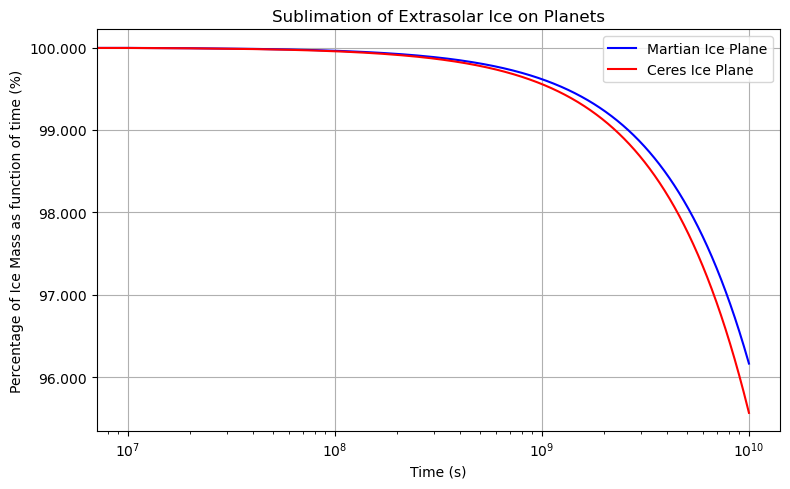

In [148]:
plt.figure(figsize=(8, 5))
plt.plot(t, m_mars_plane, label="Martian Ice Plane", color='blue')  # Convert t to hours
plt.plot(t, m_ceres_plane, label='Ceres Ice Plane', color='red')  # Convert t to hours\
plt.xlabel('Time (s)')
plt.ylabel('Percentage of Ice Mass as function of time (%)')
plt.title('Sublimation of Extrasolar Ice on Planets')
plt.xscale('log')
plt.grid(True)
#plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
#plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.legend()
plt.tight_layout()
plt.show()